# 1.2.2: Audiovisual `Scene` objects

Up until now, we've seen how we can use `AudibleLight` to generate audio-only `Scene` objects.

However, `AudibleLight` can also be used to create audio-visual soundscapes. This allows a visual representation of a `Scene` to be generated, in a similar manner to `SELDVisualSynth`[https://github.com/adrianSRoman/SELDVisualSynth/].

The resulting video can be played back for debugging `MicArray` and `Event` positions, or can be used to train a model on audio-visual data. For more information, see the [DCASE community challenges](https://dcase.community/challenge2023/task-sound-event-localization-and-detection-evaluated-in-real-spatial-sound-scenes#track-b-audiovisual-inference) on audio-visual sound event localisation and detection.

## Creating a `Scene` that supports images

Let's create a `Scene` that supports visual synthesis. To make this easier, we can pass in a directory of images using the `image_path` argument.




In [13]:
import matplotlib.pyplot as plt
from IPython.display import Image, Audio, display

from audiblelight.core import Scene
from audiblelight import utils

In [14]:
visual_scene = Scene(
    duration=10,
    backend="rlr",
    sample_rate=22050,
    video_low_power=True,
    max_overlap=1,
    video_res=(960, 480),
    video_fps=5,
    backend_kwargs=dict(
        mesh=utils.get_project_root() / "tests/test_resources/meshes/Oyens.glb"
    ),
    fg_path=utils.get_project_root() / "tests/test_resources/soundevents",
    image_path=utils.get_project_root() / "tests/test_resources/images",
)

2026-01-14 12:54:07.974 | WARNING  | audiblelight.worldstate:load_mesh_navigation_waypoints:1884 - Cannot find waypoints for mesh Oyens inside default location (/home/huw-cheston/Documents/python_projects/AudibleLight/resources/waypoints/gibson). No navigation waypoints will be loaded.


CreateContext: Context created


We can inspect the images available to our `Scene` under the `fg_images` attribute:

In [15]:
print(visual_scene.fg_images[:2])

[PosixPath('/home/huw-cheston/Documents/python_projects/AudibleLight/tests/test_resources/images/doorCupboard/27_0.jpg'), PosixPath('/home/huw-cheston/Documents/python_projects/AudibleLight/tests/test_resources/images/doorCupboard/36_0.jpg')]


Note that currently visual synthesis is only support for the ray-tracing backend (i.e., where `scene.state.name.upper() == "RLR"`).


### Optional arguments

When creating such a `Scene`, we can specify a variety of arguments, including:
- `video_fps`: the frames-per-second of the video
- `video_res`: the resolution of the video, in the format (width x height)
    - Note that the width of the video must be exactly twice that of the height, for correct perspective video rendering
- `video_low_power`: applies a variety of adjustments to improve performance on weaker hardware
- `video_overlay_distance_scale_factor`: scales the size of overlaid images depending on proximity to camera.
- `video_overlay_base_size`: the base size of overlaid images on the video, independent of distance.

For more information, including default arguments, see `Scene.__init__`.

## Adding `Event` objects with images

If we've correctly specified `image_filepath`, then image objects will automatically be added to `Event` objects, using the closest possible class to the audio file.

To show what we mean, let's start by adding a `waterTap` `Event`:

In [16]:
tap = visual_scene.add_event(
    event_type="static",
    filepath=utils.get_project_root() / "tests/test_resources/soundevents/waterTap/95709.wav",
)
print(tap.image_filepath)

2026-01-14 12:54:10.471 | INFO     | audiblelight.core:add_event:1152 - Event added successfully: Static 'Event' with alias 'event000', audio file '/home/huw-cheston/Documents/python_projects/AudibleLight/tests/test_resources/soundevents/waterTap/95709.wav' (unloaded, 0 augmentations), 1 emitter(s).


CreateContext: Context created
/home/huw-cheston/Documents/python_projects/AudibleLight/tests/test_resources/images/waterTap/32_0.jpg


We can load up the image as a `numpy` array using `Event.load_image`.

This method operates similarly to `Event.load_audio`: once an image has been loaded once, it will be cached to speed up future reads. Cached generation can be disabled with `ignore_cache`:

In [17]:
tap_image = tap.load_image()
print(tap_image.shape)

(96, 95, 3)


Let's try plotting the image.

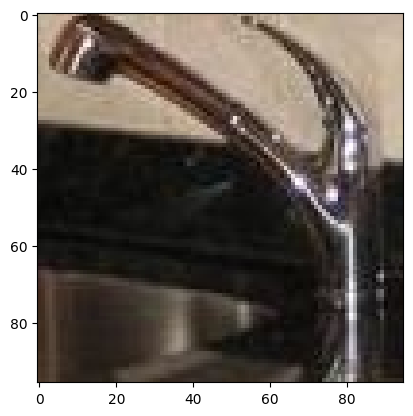

In [18]:
plt.imshow(tap_image)
plt.show()

That looks like a tap to me!

## Manually adding `Event` images

Of course, we can also add a specific image to an `Event` when adding this to a `Scene`. All we need to do is specify `image_filepath` in `Scene.add_event`.

Let's try adding an `Event` with the audio from a running tap, but the image of a telephone:

In [19]:
visual_scene.clear_events()
tapphone = visual_scene.add_event(
    event_type="static",
    filepath=utils.get_project_root() / "tests/test_resources/soundevents/waterTap/95709.wav",
    image_filepath=utils.get_project_root() / "tests/test_resources/images/telephone/3_0.jpg",
    duration=0.5,
    scene_start=2.5
)

print(tapphone.image_filepath)
print(tapphone.filepath)

CreateContext: Context created


2026-01-14 12:54:11.338 | INFO     | audiblelight.core:add_event:1152 - Event added successfully: Static 'Event' with alias 'event000', audio file '/home/huw-cheston/Documents/python_projects/AudibleLight/tests/test_resources/soundevents/waterTap/95709.wav' (unloaded, 0 augmentations), 1 emitter(s).


CreateContext: Context created
/home/huw-cheston/Documents/python_projects/AudibleLight/tests/test_resources/images/telephone/3_0.jpg
/home/huw-cheston/Documents/python_projects/AudibleLight/tests/test_resources/soundevents/waterTap/95709.wav


Now, let's play the audio and show the image, to show that the classes are different.

In [20]:
phone_img = tapphone.load_image()
tap_audio = tapphone.load_audio()

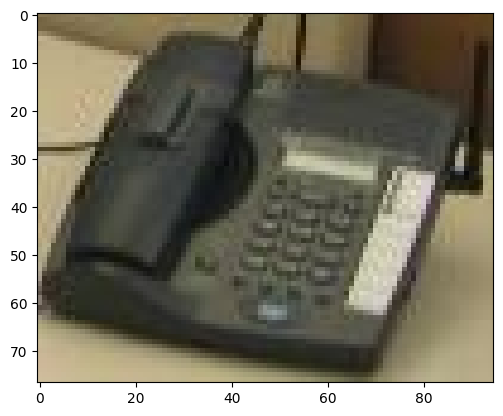

In [21]:
plt.imshow(phone_img)
plt.show()

In [22]:
Audio(tap_audio, rate=visual_scene.sample_rate)

## Audiovisual `Scene` synthesis

Now that we've added `Event` objects with images to our `Scene`, we're ready to generate a video file containing these objects.

In [23]:
# Remove all the Events
visual_scene.clear_events()
visual_scene.clear_microphones()

# Add a microphone + single Event at known positions
visual_scene.add_microphone(microphone_type="ambeovr", position=[3.5, -3.5, 1.5])
ev = visual_scene.add_event(
    event_type="static",
    filepath=utils.get_project_root() / "tests/test_resources/soundevents/telephone/30085.wav",
    image_filepath=utils.get_project_root() / "tests/test_resources/images/telephone/3_0.jpg",
    duration=0.5,
    scene_start=2.5,
    # add at a known position: definitely visible from microphone
    position=[1.5, -0.5, 0.5],
)

CreateContext: Context created
CreateContext: Context created


CreateContext: Context created


CreateContext: Context created


2026-01-14 12:54:12.812 | INFO     | audiblelight.core:add_event:1152 - Event added successfully: Static 'Event' with alias 'event000', audio file '/home/huw-cheston/Documents/python_projects/AudibleLight/tests/test_resources/soundevents/telephone/30085.wav' (unloaded, 0 augmentations), 1 emitter(s).


To generate the video file, just call `Scene.generate` with `video=True`. You can also pass `video_fname` to specify the output pattern for any video files.

By default, one video will be generated for each `MicArray` object added to the `Scene`.

In [24]:
visual_scene.generate(video=True, audio=False, metadata_dcase=False, metadata_json=False)

Rendering video...:  22%|██▏       | 11/50 [00:01<00:02, 13.63it/s]/home/huw-cheston/.cache/pypoetry/virtualenvs/audiblelight-5f5KpqNP-py3.10/lib/python3.10/site-packages/pyvista/core/filters/data_object.py:180: PyVistaDeprecationWarning: The default value of `inplace` for the filter `PolyData.transform` will change in the future. Previously it defaulted to `True`, but will change to `False`. Explicitly set `inplace` to `True` or `False` to silence this warning.
  warnings.warn(msg, PyVistaDeprecationWarning)
Rendering video...: 100%|██████████| 50/50 [00:03<00:00, 15.12it/s]


Now that we've generated the video, we can play it. We'll use `ffmpeg` to generate a `.gif` file that should play in most browsers.

Under normal use cases, however, you'll probably just use the `.mp4` file!

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

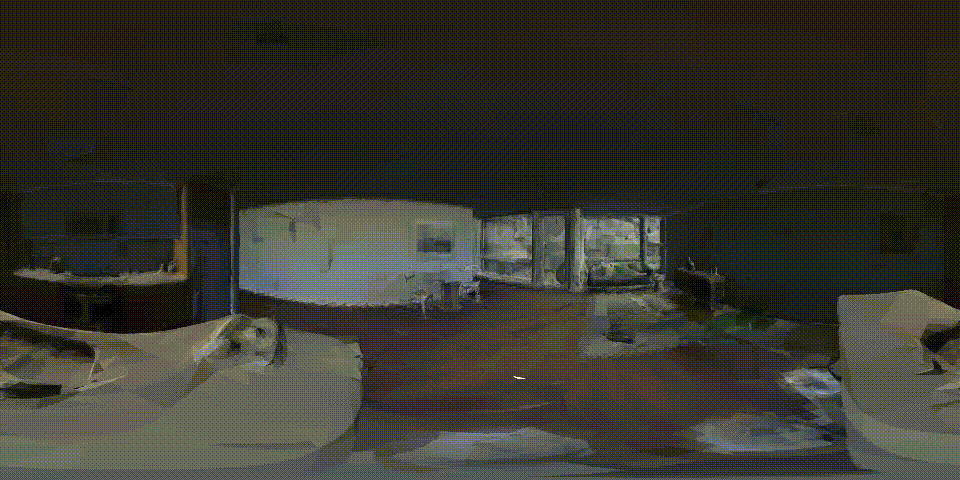

In [26]:
import subprocess
# Convert with ffmpeg
subprocess.run([
    'ffmpeg', '-i', 'video_out_mic000.mp4',
    '-vf', 'fps=5,scale=960:-1:flags=lanczos',
    '-loop', '0',
    '-y', 'video_out.gif'
])
display(Image(filename='video_out.gif'))